![Re-identification risk](assets/headers/reidentification-risk.jpg)

# 02. Re-identification risk

A hospital publishes patient records with the names removed. We put the names back by linking the
records to a public voter list on birth year, ZIP code and sex, then coarsen those fields and
measure how many links survive.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer

## Setup

Tested with Python 3.11. The next cell installs the package versions used in this notebook.

In [1]:
%pip install --quiet numpy==1.26.4 pandas==2.2.3 matplotlib==3.9.4 Faker==37.1.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from faker import Faker
from IPython.display import display

# Colours used in the figures
NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. Two tables about the same town

All people here are made up. A town has 2,000 residents and the hospital holds one record for
each of them. It releases birth year, ZIP code, sex and diagnosis, with names removed. A public
voter list has names and the same three fields for 90% of the residents.

Every resident also has a `person_id`. Neither table contains it. We keep it aside only to check
the attacker's links at the end.

In [3]:
N_PEOPLE, PUBLIC_FRACTION, SEED = 2000, 0.9, 7
fake = Faker("en_US")
fake.seed_instance(SEED)
rng = np.random.default_rng(SEED)

names = [fake.name() for _ in range(N_PEOPLE)]
birth_years = rng.integers(1945, 2006, N_PEOPLE)
regions = rng.choice(["021", "022", "024", "908"], N_PEOPLE)  # the first three ZIP digits
zip_codes = [f"{region}{n:02d}" for region, n in zip(regions, rng.integers(0, 25, N_PEOPLE))]
sexes = rng.choice(["F", "M"], N_PEOPLE)
diagnoses = rng.choice(["(none)", "hypertension", "diabetes", "depression", "cancer", "HIV"],
                       N_PEOPLE, p=[0.50, 0.16, 0.12, 0.10, 0.08, 0.04])

town = pd.DataFrame({"person_id": range(N_PEOPLE), "name": names, "birth_year": birth_years,
                     "zip": zip_codes, "sex": sexes, "diagnosis": diagnoses})

# Each source lists the residents in its own order, and the voter list misses 10% of them
hospital = town.sample(frac=1, random_state=2).reset_index(drop=True)
voter_list = town.sample(frac=PUBLIC_FRACTION, random_state=1).reset_index(drop=True)

QUASI_IDENTIFIERS = ["birth_year", "zip", "sex"]
released = hospital[QUASI_IDENTIFIERS + ["diagnosis"]]  # published by the hospital, no names
voters = voter_list[["name"] + QUASI_IDENTIFIERS]  # public, with names but no diagnoses

# Kept aside to score the attack. The attacker never sees person_id.
released_ids = hospital["person_id"].to_numpy()
voter_ids = voter_list["person_id"].to_numpy()

print(f"Hospital rows: {len(released)} | Voter list rows: {len(voters)}")
display(released.head())
display(voters.head())

Hospital rows: 2000 | Voter list rows: 1800


,birth_year,zip,sex,diagnosis
0,1999,02206,F,(none)
1,1996,90809,F,(none)
2,1956,02204,M,depression
3,1992,02219,F,(none)
4,1947,90803,M,diabetes


,name,birth_year,zip,sex
0,Caitlin Jones,1953,02214,F
1,James Barker,1949,90821,M
2,Allison Gallegos,1988,02403,F
3,Casey Kim DDS,1962,02409,F
4,Danny Davis,1978,02218,F


## 2. Quasi-identifiers

Birth year, ZIP code and sex are quasi-identifiers: none of them names a person, but together they
can single one out. Sweeney estimated that 87% of the US population is unique on 5-digit ZIP code,
sex and full date of birth.

`group_size` counts, for every record, how many records share its values (the record itself
included). A group size of 1 means the record is unique.

In [4]:
def group_size(table, fields=QUASI_IDENTIFIERS):
    """For each row, how many rows in the table have the same values in `fields`."""
    return table.groupby(fields).transform("size")


rows = []
for fields in [["sex"], ["birth_year"], ["zip"], ["birth_year", "zip"], QUASI_IDENTIFIERS]:
    sizes = group_size(released, fields)
    rows.append({"fields": " + ".join(fields), "median group size": int(sizes.median()),
                 "unique records %": round(100 * (sizes == 1).mean(), 1)})
display(pd.DataFrame(rows))

,fields,median group size,unique records %
0,sex,1015,0.0
1,birth_year,35,0.0
2,zip,21,0.0
3,birth_year + zip,1,69.7
4,birth_year + zip + sex,1,83.8


Each field on its own is shared by dozens of people or more. Combined, the three fields make 83.8%
of the hospital records unique.

## 3. Linkage attack

The attacker joins the two tables on the quasi-identifiers. A combination that appears exactly once
in each table gives an unambiguous pair: a name from the voter list and a diagnosis from the
hospital. Combinations shared by several people are skipped, because the attacker cannot tell who
is who.

`count_correct` plays the evaluator. It compares the hidden `person_id` on both sides of each link.

In [5]:
def link_records(released, voters):
    """Join the two tables on quasi-identifier values that are unique in both."""
    # Keep each row's position as a column so the evaluator can look up who it really was
    unique_released = released[group_size(released) == 1].rename_axis("released_row").reset_index()
    unique_voters = voters[group_size(voters) == 1].rename_axis("voter_row").reset_index()
    return unique_released.merge(unique_voters, on=QUASI_IDENTIFIERS)


def count_correct(links):
    """Evaluator only: how many links pair a record with the right person."""
    return (released_ids[links["released_row"]] == voter_ids[links["voter_row"]]).sum()


links = link_records(released, voters)
correct = count_correct(links)
print(f"Links found: {len(links)}")
print(f"Verified links: {correct}/{len(released)} ({correct / len(released):.1%})")
display(links[["name"] + QUASI_IDENTIFIERS + ["diagnosis"]].head(8))

Links found: 1511
Verified links: 1511/2000 (75.5%)


,name,birth_year,zip,sex,diagnosis
0,Angela Walsh,1996,90809,F,(none)
1,Mrs. Jenna French,1956,02204,M,depression
2,Julie Clark,1992,02219,F,(none)
3,Teresa Maldonado,1972,90803,F,(none)
4,James Larson,1971,90813,M,hypertension
5,Carlos Evans,1975,02413,F,hypertension
6,Lindsay Kemp,1998,02218,F,(none)
7,David Franco,1999,90811,M,(none)


Three in four patients now have their name next to their diagnosis. Every link is correct here
because everyone on the voter list is also in the hospital table. If the list also covered people
the hospital never treated, some unique matches would point to the wrong person, and the attacker
could not tell which ones.

## 4. Generalize and attack again

Generalization replaces precise values with broader ones. Birth years become 5-, 10- or 20-year
bands, and ZIP codes are cut to their first 4 or 3 digits (the first three digits are the region).
The release format is public, so the attacker coarsens the voter list the same way before linking.

For each level we also record the smallest group in the released table. This is the k of
k-anonymity: every record shares its values with at least k-1 others. The last column, the fewest
distinct diagnoses in any group, comes back in section 5.

In [6]:
def generalize(table, year_band, zip_digits):
    """Round birth years down to `year_band`-year bands and cut the ZIP to `zip_digits` digits."""
    table = table.copy()
    table["birth_year"] = table["birth_year"] // year_band * year_band
    table["zip"] = table["zip"].str[:zip_digits]
    return table


LEVELS = {  # label: (years per band, ZIP digits kept)
    "Birth year\n5-digit ZIP": (1, 5),
    "5-year band\n4-digit ZIP": (5, 4),
    "Decade\n3-digit ZIP": (10, 3),
    "20-year band\n3-digit ZIP": (20, 3),
}

rows = []
for label, (year_band, zip_digits) in LEVELS.items():
    coarse_released = generalize(released, year_band, zip_digits)
    coarse_voters = generalize(voters, year_band, zip_digits)
    correct = count_correct(link_records(coarse_released, coarse_voters))
    groups = coarse_released.groupby(QUASI_IDENTIFIERS)
    rows.append({"level": label.replace("\n", " / "), "verified links": correct,
                 "re-identified %": 100 * correct / len(released),
                 "minimum k": groups.size().min(),
                 "fewest distinct diagnoses": groups["diagnosis"].nunique().min()})

results = pd.DataFrame(rows)
display(results)

,level,verified links,re-identified %,minimum k,fewest distinct diagnoses
0,Birth year / 5-digit ZIP,1511,75.55,1,1
1,5-year band / 4-digit ZIP,12,0.60,1,1
2,Decade / 3-digit ZIP,0,0.00,14,3
3,20-year band / 3-digit ZIP,0,0.00,17,4


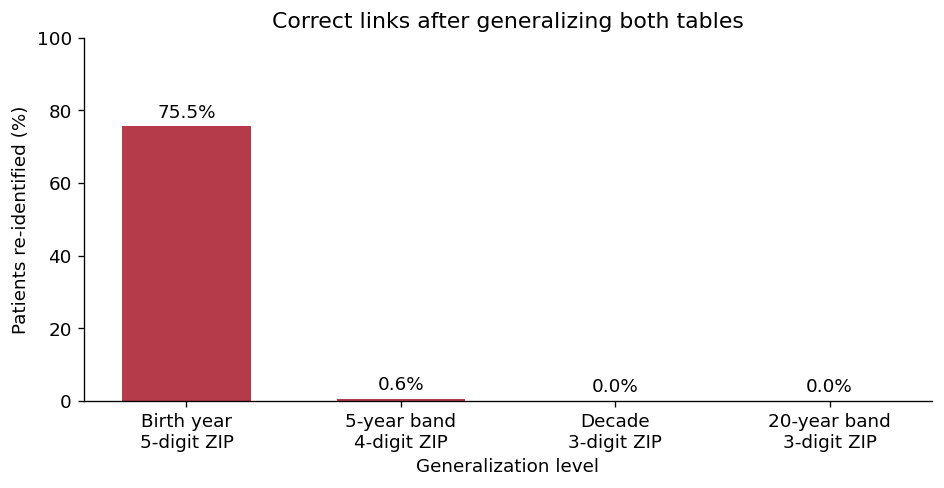

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(list(LEVELS), results["re-identified %"], color=RED, width=0.6)
ax.bar_label(bars, fmt="{:.1f}%", padding=3)
ax.set(ylim=(0, 100), xlabel="Generalization level", ylabel="Patients re-identified (%)",
       title="Correct links after generalizing both tables")
fig.tight_layout()
plt.show()

With 5-year bands and 4-digit ZIP codes only 12 patients can still be linked, and from decades
upward none. Real releases carry more columns, and new public sources appear over time. Whether a
table can be linked depends on what data exists outside it, today and later.

The attack needs a combination that is unique on both sides. The next chart shows how large each
record's group is at every level.

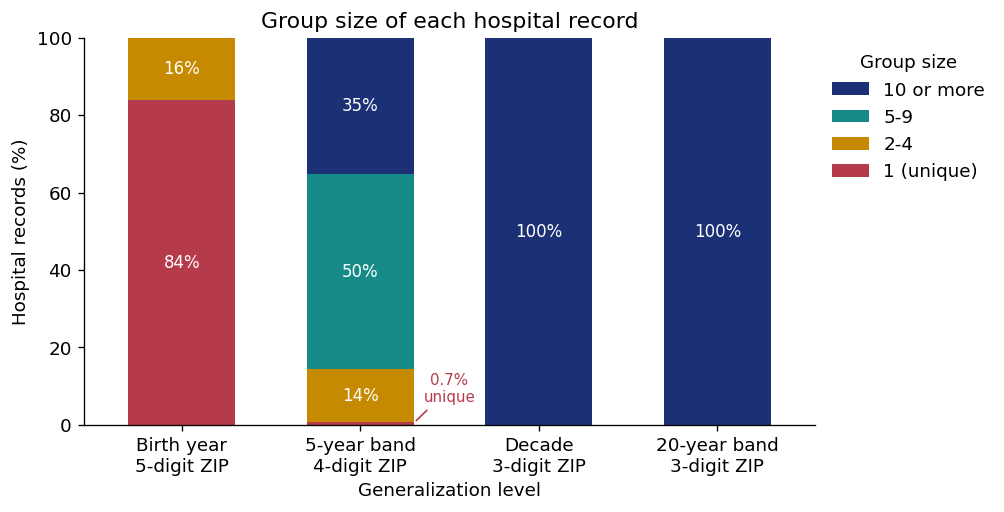

In [8]:
bins, bin_labels = [0, 1, 4, 9, np.inf], ["1 (unique)", "2-4", "5-9", "10 or more"]
shares = {}
for label, (year_band, zip_digits) in LEVELS.items():
    sizes = group_size(generalize(released, year_band, zip_digits))
    shares[label] = pd.cut(sizes, bins, labels=bin_labels).value_counts(normalize=True) * 100
shares = pd.DataFrame(shares).T

fig, ax = plt.subplots(figsize=(8.5, 4.4))
shares.plot.bar(ax=ax, stacked=True, color=[RED, GOLD, TEAL, NAVY], width=0.6, rot=0)
# Label only segments big enough to hold text
for bars in ax.containers:
    ax.bar_label(bars, labels=[f"{v:.0f}%" if v >= 5 else "" for v in bars.datavalues],
                 label_type="center", color="white", fontsize=10)
# The unique slice of the second bar is too thin to see, so point at it
ax.annotate(f"{shares.iloc[1, 0]:.1f}%\nunique", xy=(1.3, 0.5), xytext=(1.5, 6), ha="center",
            color=RED, fontsize=9, arrowprops=dict(arrowstyle="-", color=RED))
# List the legend top to bottom, in the same order as the stacks
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="Group size", frameon=False,
          loc="upper left", bbox_to_anchor=(1, 1))
ax.set(ylim=(0, 100), xlabel="Generalization level", ylabel="Hospital records (%)",
       title="Group size of each hospital record")
fig.tight_layout()
plt.show()

At full detail 84% of the records are alone in their group. With 5-year bands fewer than 1% are,
and from decades upward every group has at least 14 people.

## 5. Hidden in a group, sensitive value still revealed

k-anonymity hides which row belongs to whom. It does not help when everyone in a group has the same
diagnosis: an attacker who knows a neighbour is in that group learns the diagnosis without finding
the row. l-diversity adds a second rule: every group must contain at least l different sensitive
values. The last column of the table in section 4 is the l each level reaches.

Below we count the groups that hide identities (2 or more records) but share a single value in the
diagnosis column, and list which value they share.

In [9]:
rows = []
for label, (year_band, zip_digits) in LEVELS.items():
    groups = generalize(released, year_band, zip_digits).groupby(QUASI_IDENTIFIERS)["diagnosis"]
    stats = pd.DataFrame({"size": groups.size(), "diagnoses": groups.nunique(),
                          "value": groups.first()})
    hidden = stats[stats["size"] >= 2]
    same_value = hidden[hidden["diagnoses"] == 1]
    # Patients per shared value, largest first
    revealed = same_value.groupby("value")["size"].sum().sort_values(ascending=False, kind="stable")
    rows.append({"level": label.replace("\n", " / "), "groups of 2 or more": len(hidden),
                 "of these, one value": len(same_value),
                 "patients in those groups": same_value["size"].sum(),
                 "shared value (patients)": ", ".join(f"{v} {n}" for v, n in revealed.items())})

with pd.option_context("display.max_colwidth", None):  # show the full list of values
    display(pd.DataFrame(rows))

,level,groups of 2 or more,"of these, one value",patients in those groups,shared value (patients)
0,Birth year / 5-digit ZIP,156,42,84,"(none) 72, hypertension 6, HIV 2, depression 2, diabetes 2"
1,5-year band / 4-digit ZIP,289,15,52,(none) 52
2,Decade / 3-digit ZIP,56,0,0,
3,20-year band / 3-digit ZIP,32,0,0,


At full detail 84 patients sit in groups where everyone has the same value, and 12 of them share a
real diagnosis, HIV for two of them. With 5-year bands the 52 patients in such groups all have
"(none)", so the attacker still learns that these people have none of the listed conditions. From
decades upward every group mixes at least three values.

## Experiments

1. Set `PUBLIC_FRACTION = 0.5` and run the notebook again. How much does the re-identified share
   drop when only half the town is on the voter list?
2. Add `"Decade\n4-digit ZIP": (10, 4)` to `LEVELS`, between the 5-year and decade levels. Where
   does it land for correct links and minimum k?
3. Let the hospital treat only 70% of the town: in section 1, change `frac=1` to `frac=0.7` in the
   `hospital` line. Compare `len(links)` with the verified links. Some unique matches are now wrong.

**References:** [Sweeney, k-anonymity (2002)](https://dataprivacylab.org/dataprivacy/projects/kanonymity/kanonymity.pdf) ·
[Machanavajjhala et al., l-diversity (2007)](https://doi.org/10.1145/1217299.1217302)